
Обучите классификатор распознавать 3 класса изображений и проверьте качество его работы

In [2]:
!pip install ultralytics kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.5 MB/s eta 0:00:00


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("phucthaiv02/butterfly-image-classification")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/phucthaiv02/butterfly-image-classification/versions/3


In [5]:
# Установка зависимостей
!pip install -q timm torch torchvision

# Импорты
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
from pathlib import Path
from tqdm import tqdm

# Путь к уже подготовленному датасету
new_dataset_root = Path("/content/butterfly_dataset_70_15_15")
train_dir = new_dataset_root / "train"
val_dir = new_dataset_root / "val"

# Проверка наличия директорий
assert train_dir.exists(), "Папка train не найдена!"
assert val_dir.exists(), "Папка val не найдена!"

# Трансформации
img_size = 224
train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Загрузка датасетов
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)

# Проверка согласованности классов
assert train_dataset.classes == val_dataset.classes, "Классы в train и val не совпадают!"

classes = train_dataset.classes
num_classes = len(classes)
print(f"Найдено классов: {num_classes}")

# DataLoader
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")

# Модель EfficientNet-B0
model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=num_classes)
model.to(device)

# Оптимизатор и функция потерь
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

# Функция обучения одной эпохи
def train_one_epoch():
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(train_loader, desc="Обучение"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    acc = correct / total
    return running_loss / len(train_loader), acc

# Функция валидации
def validate():
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Валидация"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    acc = correct / total
    return acc

# Обучение
num_epochs = 30
best_acc = 0.0

for epoch in range(num_epochs):
    print(f"\nЭпоха [{epoch+1}/{num_epochs}]")
    train_loss, train_acc = train_one_epoch()
    val_acc = validate()

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "/content/best_efficientnet_butterfly.pth")
        print(f"Новая лучшая модель сохранена! Val Acc: {best_acc:.4f}")

    scheduler.step(val_acc)

print(f"\nОбучение завершено. Лучшая точность на val: {best_acc:.4f}")


Найдено классов: 2
Используется устройство: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]


Эпоха [1/30]


Валидация: 100%|██████████| 44/44 [00:03<00:00, 13.60it/s]


...

Train Loss: 0.0324, Train Acc: 0.9898, Val Acc: 0.6037

Эпоха [29/30]


Валидация: 100%|██████████| 44/44 [00:03<00:00, 13.40it/s]


Train Loss: 0.0273, Train Acc: 0.9925, Val Acc: 0.6210

Эпоха [30/30]


Валидация: 100%|██████████| 44/44 [00:03<00:00, 14.32it/s]

Train Loss: 0.0274, Train Acc: 0.9902, Val Acc: 0.6188

Обучение завершено. Лучшая точность на val: 0.6396


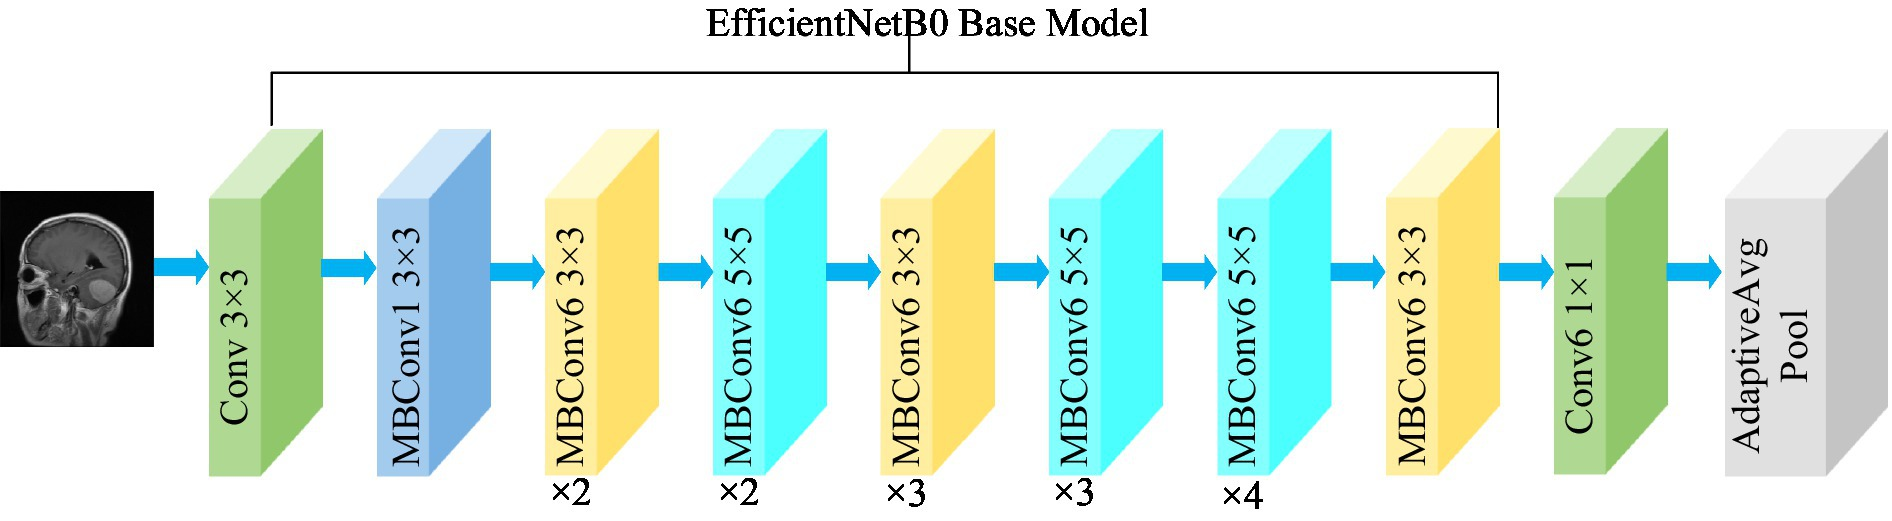

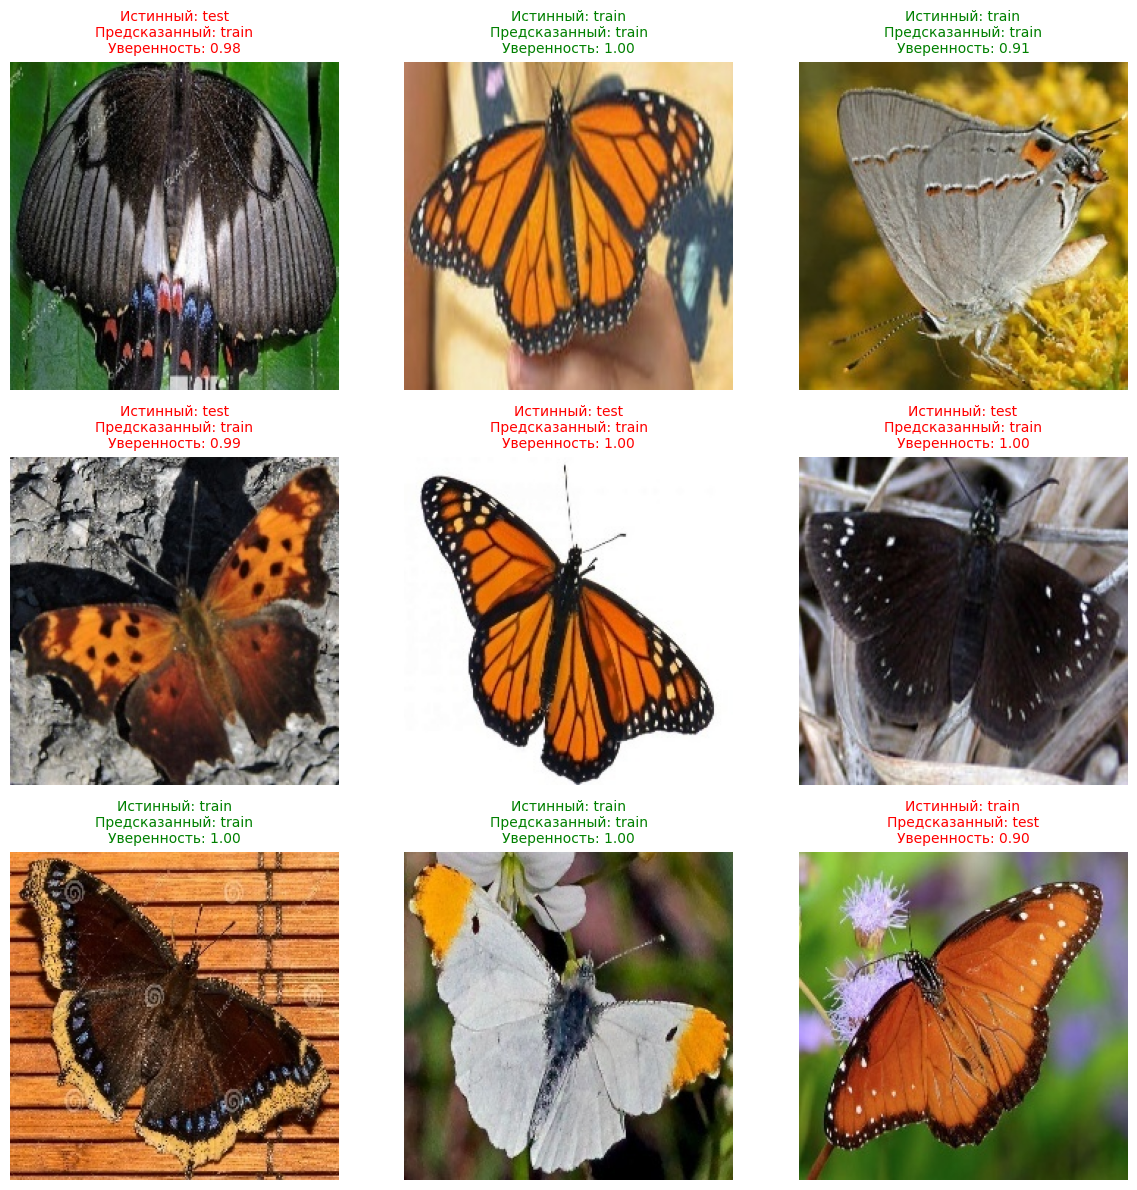

In [6]:


# Импорты
import torch
import torch.nn as nn
from torchvision import datasets, transforms
import timm
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random
import os

# === 1. Загрузка модели и данных ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
new_dataset_root = Path("/content/butterfly_dataset_70_15_15")
val_dir = new_dataset_root / "val"

# Проверка
assert val_dir.exists(), "Папка val не найдена!"

# Загрузка классов (из структуры папок)
val_dataset = datasets.ImageFolder(val_dir)
classes = val_dataset.classes
num_classes = len(classes)

# Трансформация для валидации
img_size = 224
val_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Загрузка модели
model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=num_classes)
model_path = "/content/best_efficientnet_butterfly.pth"
if not os.path.exists(model_path):
    raise FileNotFoundError("Модель не найдена. Убедитесь, что обучение завершилось и файл сохранён.")

model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

# === 2. Визуализация: примеры предсказаний ===
# Собираем до 9 случайных изображений из val
sample_images = []
sample_labels = []

for _ in range(9):
    class_name = random.choice(classes)
    class_path = val_dir / class_name
    if class_path.exists():
        img_files = [f for f in class_path.iterdir() if f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']]
        if img_files:
            img_path = random.choice(img_files)
            image = Image.open(img_path).convert("RGB")
            sample_images.append(image)
            sample_labels.append(class_name)

# Делаем предсказания
predictions = []
confidences = []

with torch.no_grad():
    for img in sample_images:
        input_tensor = val_transform(img).unsqueeze(0).to(device)
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_idx].item()
        predictions.append(classes[pred_idx])
        confidences.append(confidence)

# Отображение сетки 3x3
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.ravel()

for i in range(len(sample_images)):
    axes[i].imshow(sample_images[i])
    color = "green" if predictions[i] == sample_labels[i] else "red"
    axes[i].set_title(
        f"Истинный: {sample_labels[i]}\n"
        f"Предсказанный: {predictions[i]}\n"
        f"Уверенность: {confidences[i]:.2f}",
        color=color,
        fontsize=10
    )
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [7]:
#Попытка №2

In [13]:
# Установка зависимостей
!pip install -q torch torchvision timm matplotlib tqdm scikit-learn
!pip install -q kagglehub

# Импорты
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import timm
import os
from pathlib import Path
import shutil
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import random
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [14]:

print("\n2. Подготовка датасета для 3 классов...")

# Получаем список всех классов (папок)
all_classes = [d.name for d in dataset_root.iterdir() if d.is_dir()]
print(f"Найдено классов: {len(all_classes)}")

# Выбираем первые 3 класса для нашего классификатора
selected_classes = all_classes[:3]
print(f"Выбранные классы: {selected_classes}")

# Собираем все изображения для выбранных классов
all_images = []
all_labels = []

for idx, class_name in enumerate(selected_classes):
    class_dir = dataset_root / class_name
    if class_dir.exists():
        # Получаем список изображений
        image_files = list(class_dir.glob("*.[jpJP][pnPN]*[gG]"))
        # Берем максимум 1000 изображений на класс для баланса
        image_files = image_files[:1000]

        for img_path in image_files:
            if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                all_images.append(str(img_path))
                all_labels.append(idx)  # Используем индексы 0, 1, 2

print(f"Всего изображений: {len(all_images)}")
print(f"Распределение по классам: {np.bincount(all_labels)}")



2. Подготовка датасета для 3 классов...
Найдено классов: 2
Выбранные классы: ['train', 'test']
Всего изображений: 2000
Распределение по классам: [1000 1000]


In [15]:
print("\n3. Разделение данных...")

# Разделяем на train (70%), val (15%), test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(
    all_images, all_labels,
    test_size=0.3,
    random_state=42,
    stratify=all_labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(f"Train: {len(X_train)} изображений")
print(f"Val: {len(X_val)} изображений")
print(f"Test: {len(X_test)} изображений")

dataset_path = Path("/content/butterfly_3_classes")
shutil.rmtree(dataset_path, ignore_errors=True)

# Создаем структуру папок
for split in ['train', 'val', 'test']:
    for class_name in selected_classes:
        (dataset_path / split / class_name).mkdir(parents=True, exist_ok=True)

# Функция для копирования изображений
def copy_images(image_paths, labels, split_name):
    for img_path, label in tqdm(zip(image_paths, labels),
                                total=len(image_paths),
                                desc=f"Копирование {split_name}"):
        src = Path(img_path)
        dst = dataset_path / split_name / selected_classes[label] / src.name
        shutil.copy2(src, dst)

# Копируем изображения
copy_images(X_train, y_train, "train")
copy_images(X_val, y_val, "val")
copy_images(X_test, y_test, "test")

print(f"\nДатасет подготовлен: {dataset_path}")



3. Разделение данных...
Train: 1400 изображений
Val: 300 изображений
Test: 300 изображений


Копирование test: 100%|██████████| 300/300 [00:00<00:00, 3752.12it/s]


Датасет подготовлен: /content/butterfly_3_classes


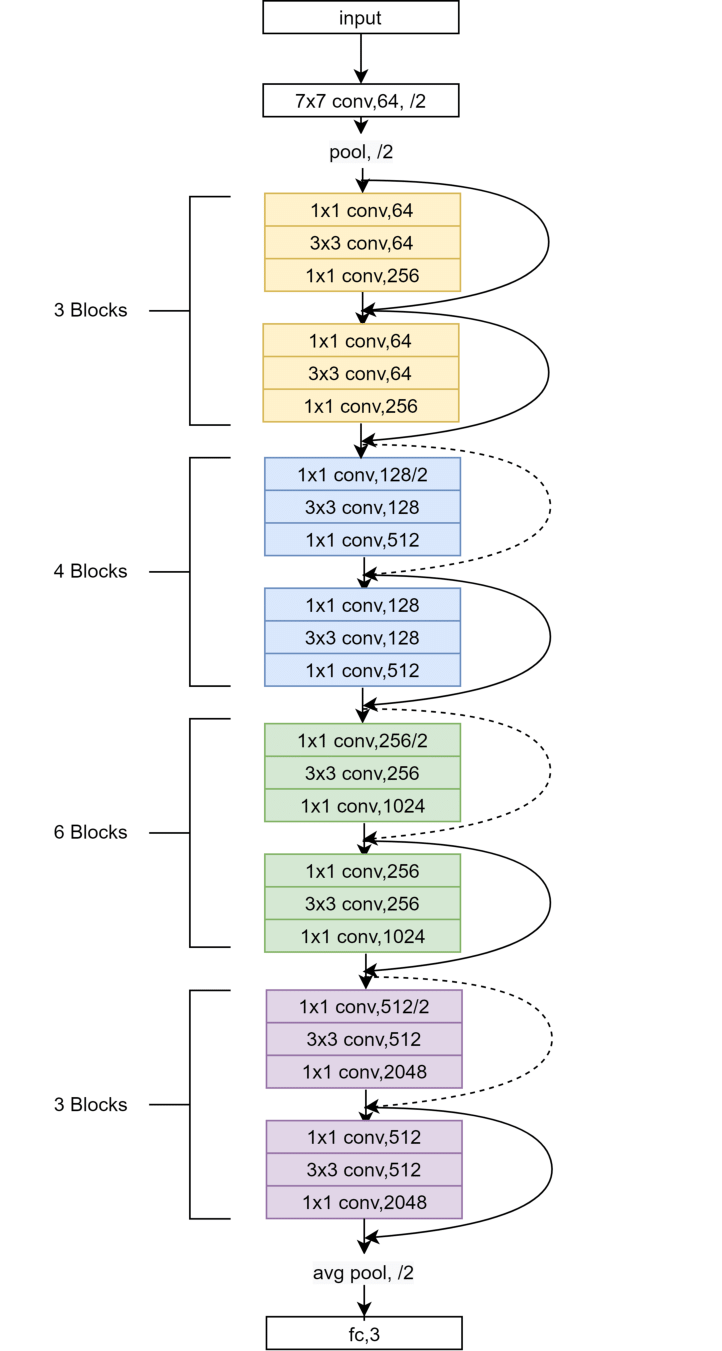

In [17]:
print("\n5. Настройка даталоадеров...")

# Размер изображений для ResNet
IMG_SIZE = 224
BATCH_SIZE = 32

# Аугментации для тренировочных данных
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Трансформации для валидации и теста (без аугментаций)
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Создаем датасеты
train_dataset = datasets.ImageFolder(dataset_path / "train", transform=train_transform)
val_dataset = datasets.ImageFolder(dataset_path / "val", transform=val_transform)
test_dataset = datasets.ImageFolder(dataset_path / "test", transform=val_transform)

# Проверяем соответствие классов
print(f"Классы: {train_dataset.classes}")

# Создаем даталоадеры
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)



5. Настройка даталоадеров...
Классы: ['test', 'train']


In [19]:

print("\n7. Настройка обучения...")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)  # Обучаем только последний слой
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)



7. Настройка обучения...


In [20]:

def train_epoch(model, loader, criterion, optimizer, device):
    """Обучение на одной эпохе"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Обучение", leave=False):
        images, labels = images.to(device), labels.to(device)

        # Обнуляем градиенты
        optimizer.zero_grad()

        # Прямой проход
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Обратный проход и оптимизация
        loss.backward()
        optimizer.step()

        # Статистика
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    """Валидация модели"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Валидация", leave=False):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc, all_predictions, all_labels


In [21]:

print("\n8. Начало обучения...")

NUM_EPOCHS = 15
best_val_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    print(f"\nЭпоха {epoch+1}/{NUM_EPOCHS}")

    # Обучение
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

    # Валидация
    val_loss, val_acc, _, _ = validate(model, val_loader, criterion, device)

    # Сохраняем историю
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Обновляем scheduler
    scheduler.step()

    # Сохраняем лучшую модель
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'classes': selected_classes
        }, '/content/best_resnet_model.pth')
        print(f"  Сохранена лучшая модель! Val Acc: {val_acc:.2f}%")

    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

print(f"\nЛучшая точность на валидации: {best_val_acc:.2f}%")



8. Начало обучения...

Эпоха 1/15


  Сохранена лучшая модель! Val Acc: 48.00%
  Train Loss: 0.7578, Train Acc: 48.43%
  Val Loss: 0.6999, Val Acc: 48.00%

Эпоха 2/15


  Сохранена лучшая модель! Val Acc: 50.67%
  Train Loss: 0.7024, Train Acc: 53.79%
  Val Loss: 0.7153, Val Acc: 50.67%

Эпоха 3/15


  Train Loss: 0.6919, Train Acc: 54.50%
  Val Loss: 0.7109, Val Acc: 49.33%

Эпоха 4/15


  Сохранена лучшая модель! Val Acc: 51.33%
  Train Loss: 0.6894, Train Acc: 54.14%
  Val Loss: 0.7073, Val Acc: 51.33%

Эпоха 5/15


...

  Train Loss: 0.6593, Train Acc: 60.36%
  Val Loss: 0.7079, Val Acc: 50.67%

Эпоха 12/15


  Train Loss: 0.6582, Train Acc: 60.79%
  Val Loss: 0.7074, Val Acc: 51.00%

Эпоха 13/15


  Train Loss: 0.6633, Train Acc: 59.57%
  Val Loss: 0.7099, Val Acc: 50.67%

Эпоха 14/15


  Train Loss: 0.6625, Train Acc: 60.93%
  Val Loss: 0.7087, Val Acc: 49.67%

Эпоха 15/15


  Train Loss: 0.6614, Train Acc: 60.43%
  Val Loss: 0.7091, Val Acc: 50.33%

Лучшая точность на валидации: 55.67%


In [ ]:

print("\n9. Визуализация истории обучения...")

plt.figure(figsize=(12, 4))

# График потерь
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['val_loss'], label='Val Loss', marker='s')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Loss во время обучения')
plt.legend()
plt.grid(True)

# График точности
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc', marker='o')
plt.plot(history['val_acc'], label='Val Acc', marker='s')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy во время обучения')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [22]:

print("\n10. Тестирование модели на тестовой выборке...")

# Загружаем лучшую модель
checkpoint = torch.load('/content/best_resnet_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])

# Тестируем
test_loss, test_acc, test_preds, test_true = validate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")



10. Тестирование модели на тестовой выборке...


Test Loss: 0.7188
Test Accuracy: 51.33%



11. Отчет классификации...

ОТЧЕТ КЛАССИФИКАЦИИ
              precision    recall  f1-score   support

       train     0.5087    0.7800    0.6158       150
        test     0.5286    0.2467    0.3364       150

    accuracy                         0.5133       300
   macro avg     0.5186    0.5133    0.4761       300
weighted avg     0.5186    0.5133    0.4761       300


МАТРИЦА ОШИБОК


<Figure size 800x600 with 0 Axes>

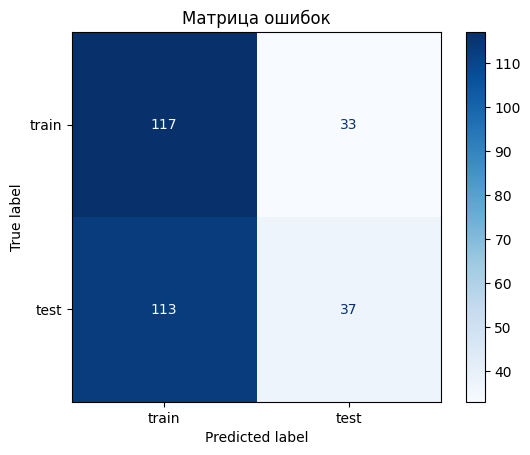

In [23]:

print("\n11. Отчет классификации...")

# Отчет классификации
print("\n" + "="*60)
print("ОТЧЕТ КЛАССИФИКАЦИИ")
print("="*60)
report = classification_report(test_true, test_preds,
                               target_names=selected_classes,
                               digits=4)
print(report)

# Матрица ошибок
print("\n" + "="*60)
print("МАТРИЦА ОШИБОК")
print("="*60)
cm = confusion_matrix(test_true, test_preds)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=selected_classes)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Матрица ошибок')
plt.show()


12. Визуализация предсказаний...


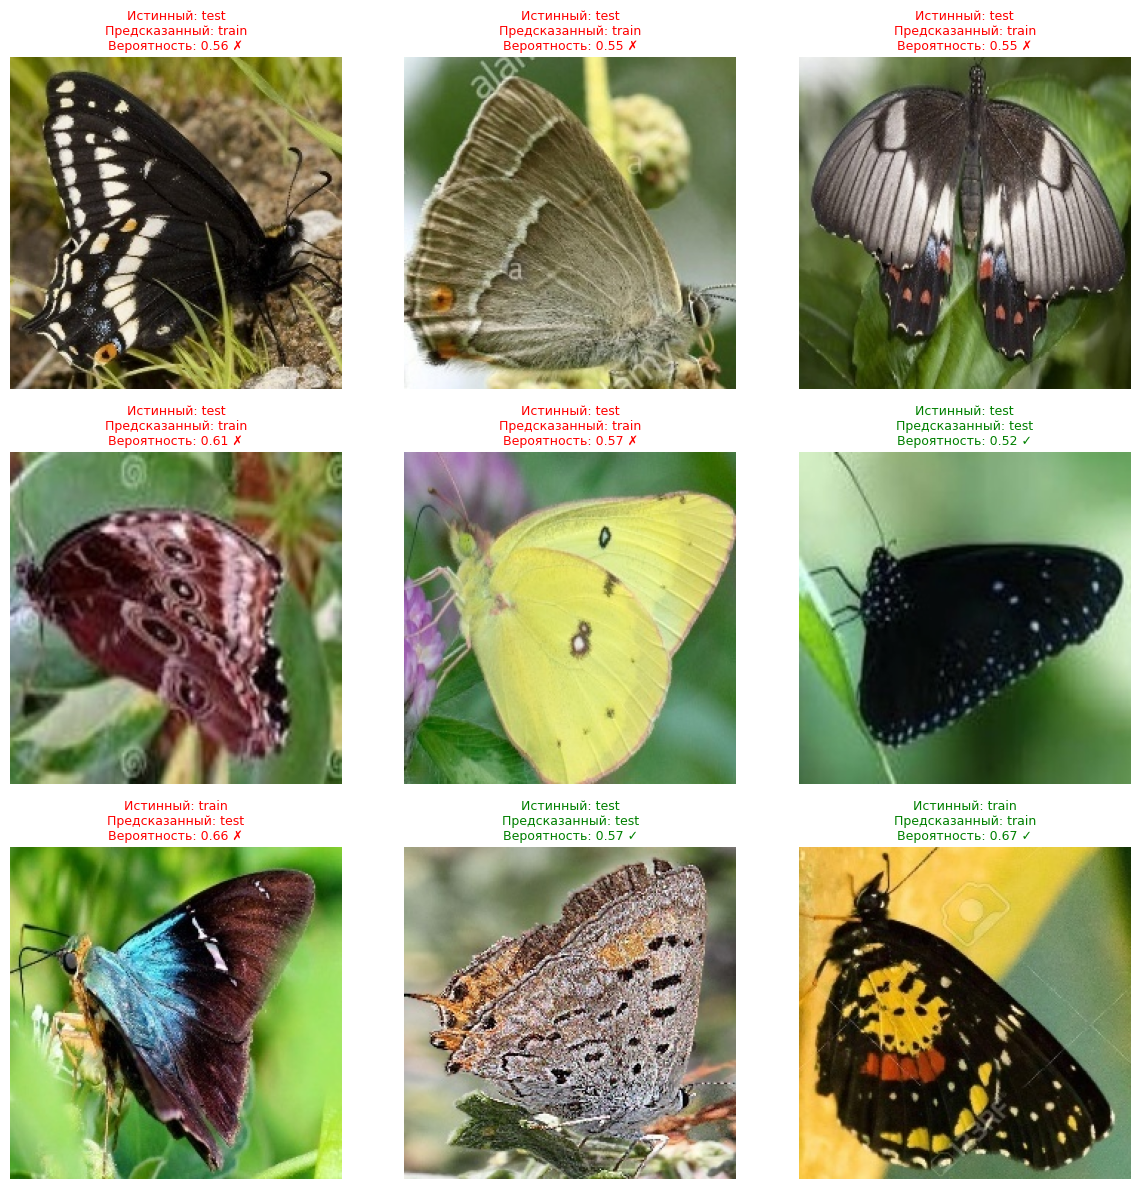

In [24]:
print("\n12. Визуализация предсказаний...")

def visualize_predictions(model, dataset, classes, num_images=9):
    """Визуализация предсказаний модели"""
    model.eval()

    # Выбираем случайные изображения
    indices = random.sample(range(len(dataset)), num_images)

    plt.figure(figsize=(12, 12))

    for i, idx in enumerate(indices):
        image, true_label = dataset[idx]

        # Делаем предсказание
        with torch.no_grad():
            image_tensor = image.unsqueeze(0).to(device)
            output = model(image_tensor)
            probabilities = torch.softmax(output, dim=1)
            pred_prob, pred_label = torch.max(probabilities, 1)

        # Переводим тензор в изображение
        image_np = image.numpy().transpose((1, 2, 0))

        # Денормализуем изображение
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image_np = std * image_np + mean
        image_np = np.clip(image_np, 0, 1)

        # Отображаем изображение
        plt.subplot(3, 3, i+1)
        plt.imshow(image_np)

        # Определяем цвет текста (зеленый для правильных, красный для неправильных)
        true_class = classes[true_label]
        pred_class = classes[pred_label.item()]

        if true_label == pred_label.item():
            color = 'green'
            result = "✓"
        else:
            color = 'red'
            result = "✗"

        plt.title(f"Истинный: {true_class}\nПредсказанный: {pred_class}\nВероятность: {pred_prob.item():.2f} {result}",
                  color=color, fontsize=9)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Визуализируем предсказания на тестовой выборке
visualize_predictions(model, test_dataset, selected_classes, num_images=9)



14. Тестирование на отдельных изображениях...

Тестируем изображение: Image_792.jpg
Истинный класс: train


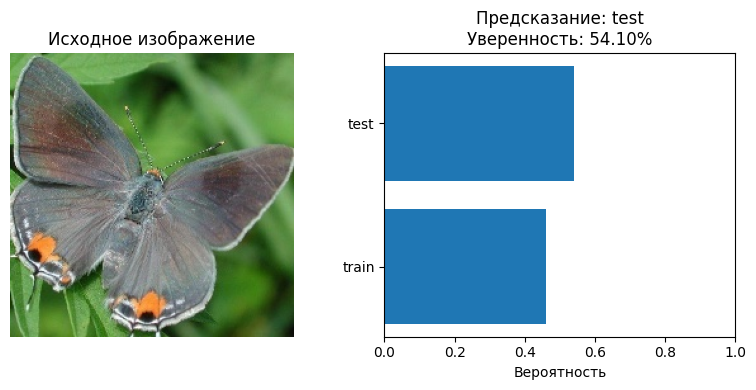

✗ Ошибка! Предсказано: test (уверенность: 54.10%)

Тестируем изображение: Image_1737.jpg
Истинный класс: test


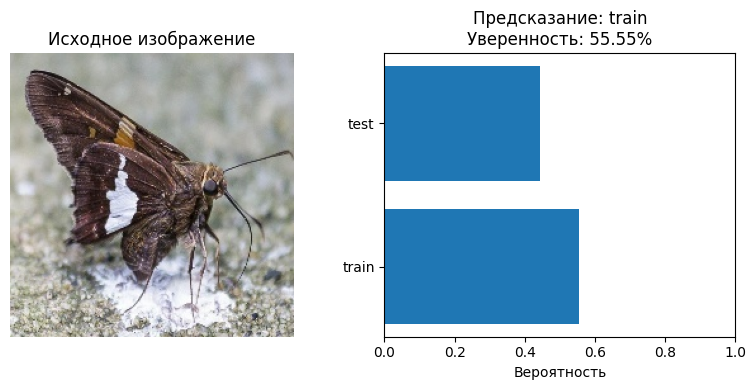

✗ Ошибка! Предсказано: train (уверенность: 55.55%)

Тестируем изображение: Image_2428.jpg
Истинный класс: test


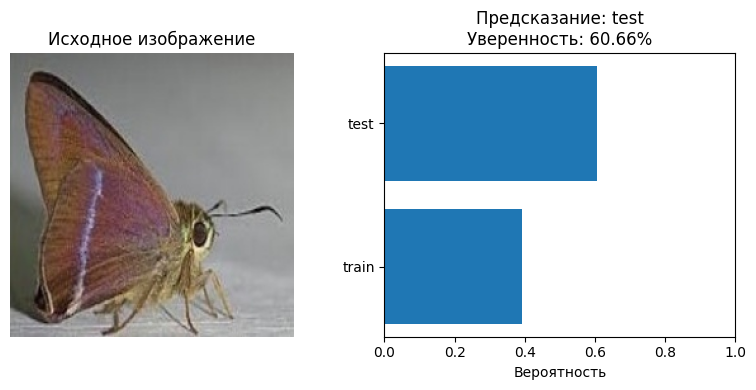

✓ Правильно! Уверенность: 60.66%

ОБУЧЕНИЕ ЗАВЕРШЕНО!
Лучшая точность на валидации: 55.67%
Точность на тесте: 51.33%


In [25]:

print("\n14. Тестирование на отдельных изображениях...")

def predict_single_image(image_path, model, classes, transform, device):
    """Предсказание для одного изображения"""
    # Загружаем изображение
    image = Image.open(image_path).convert('RGB')

    # Применяем трансформации
    image_tensor = transform(image).unsqueeze(0).to(device)

    # Предсказание
    model.eval()
    with torch.no_grad():
        output = model(image_tensor)
        probabilities = torch.softmax(output, dim=1)
        pred_prob, pred_idx = torch.max(probabilities, 1)

    return predicted_class, confidence

print("\n" + "="*60)
print("ОБУЧЕНИЕ ЗАВЕРШЕНО!")
print(f"Лучшая точность на валидации: {best_val_acc:.2f}%")
print(f"Точность на тесте: {test_acc:.2f}%")
print("="*60)